# BuildersVault Social Services Hackathon Track 1 Quickstart

**Track 1: Inter-Org Referral and Care Coordination**

**Standards in scope:** HIFIS 4 referral module, BC Coordinated Access, AIRS taxonomy, VI-SPDAT acuity, PIPA / FOIPPA / OCAP consent law.

## What this notebook does in 30 seconds

Loads the 7 synthetic datasets, runs basic schema and quality checks, builds a golden joined view that most teams will build on top of, does some quick EDA, and runs a rule-based duplicate-detection baseline so you have a number to beat.

## What the data represents

- **9 mock Victoria-area social service orgs** modeled on real HIFIS 4 deployments plus BC Coordinated Access partners.
- **800 clients** with realistic demographic messiness (missing DOBs, nickname variants, partial addresses, OCAP-flagged Indigenous clients).
- **3,000 referrals** across the full HIFIS lifecycle (submitted, accepted, declined, completed, withdrawn, no-show).
- **10,000 service encounters** spanning shelter nights, case-management sessions, outreach contacts, health visits.
- **5,000 consent records** with active, expired, withdrawn, and scope-mismatched states.
- **Ground-truth duplicate flags** with 300 true positives and 200 decoy near-duplicates so you can actually score your entity-resolution work.

## 4 concrete challenges to pick from

1. **Duplicate detection and merge** across agencies without violating OCAP (a client can exist in 3 orgs under 3 spellings).
2. **Consent-gap surfacing** so caseworkers see when data sharing is unlawful before they act.
3. **Referral lifecycle bottlenecks** so coordinators see where referrals stall or die.
4. **Falling-through-the-gaps risk detection** for chronically-vulnerable clients who are losing touch with the system.

Pick one. Go deep. Judges care about domain grounding more than model complexity.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from pathlib import Path
from difflib import SequenceMatcher

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

DATA_DIR = Path('../data/raw')

expected_files = [
    'organizations.parquet',
    'clients.parquet',
    'referrals.parquet',
    'service_encounters.parquet',
    'consent_records.parquet',
    'data_sharing_agreements.parquet',
    'duplicate_flags.parquet',
]

missing = [f for f in expected_files if not (DATA_DIR / f).exists()]
if missing:
    print('Missing data files:', missing)
    print('Run: python ../generator/generate.py')
else:
    print(f'All {len(expected_files)} data files present in {DATA_DIR.resolve()}')


All 7 data files present in C:\Users\dylwh\OneDrive\Desktop\Projects\Social Services Hackathon BuilderVault 2026\buildersvault-hackathon-kit\tracks\referral-care-coordination\data\raw


In [3]:
orgs = pd.read_parquet(DATA_DIR / 'organizations.parquet')
clients = pd.read_parquet(DATA_DIR / 'clients.parquet')
referrals = pd.read_parquet(DATA_DIR / 'referrals.parquet')
encounters = pd.read_parquet(DATA_DIR / 'service_encounters.parquet')
consent = pd.read_parquet(DATA_DIR / 'consent_records.parquet')
dsa = pd.read_parquet(DATA_DIR / 'data_sharing_agreements.parquet')
dup_flags = pd.read_parquet(DATA_DIR / 'duplicate_flags.parquet')

tables = {
    'orgs': orgs,
    'clients': clients,
    'referrals': referrals,
    'encounters': encounters,
    'consent': consent,
    'dsa': dsa,
    'duplicate_flags': dup_flags,
}

for name, df in tables.items():
    print(f'{name:20s} shape = {df.shape}')


orgs                 shape = (9, 19)
clients              shape = (840, 40)
referrals            shape = (3000, 19)
encounters           shape = (10000, 17)
consent              shape = (5000, 21)
dsa                  shape = (4, 7)
duplicate_flags      shape = (500, 8)


In [4]:
rows = []
for name, df in tables.items():
    for col in df.columns:
        nulls = df[col].isna().sum()
        rows.append({
            'table': name,
            'column': col,
            'dtype': str(df[col].dtype),
            'null_count': int(nulls),
            'null_pct': round(100.0 * nulls / max(len(df), 1), 2),
        })

null_summary = pd.DataFrame(rows)
print('Top 15 columns by null percentage:')
null_summary.sort_values('null_pct', ascending=False).head(15)


Top 15 columns by null percentage:


,table,column,dtype,null_count,null_pct
94,encounters,diversion_destination,object,9839,98.39
74,referrals,cancelled_at,datetime64[ns],2853,95.10
105,consent,sharing_scope_agency_ids,object,4684,93.68
109,consent,withdrawal_date,object,4648,92.96
88,encounters,related_referral_id,object,9227,92.27
115,consent,notes,object,4468,89.36
110,consent,superseded_date,object,4264,85.28
68,referrals,status_reason,object,2515,83.83
24,clients,aliases,object,704,83.81
52,clients,ocap_governing_nation,object,695,82.74


In [5]:
# for name, df in tables.items():
#     for col in df.columns:
        
#     print(f'\n--- {name} ---')
#     print(list(df.columns))

rows = []
for name, df in tables.items():
    print(f'\n--- {name} ---')
    for col in df.columns:
        print(col)


--- orgs ---
org_id
org_name
org_type
cluster_id
address_street
address_city
address_province
address_postal
service_taxonomy_code
target_population
genders_served
age_min
age_max
capacity_total_slots
capacity_occupied_slots
waitlist_flag
waitlist_size
waitlist_average_days
last_capacity_update

--- clients ---
client_id
primary_org_id
first_name
last_name
middle_name
aliases
dob
age
gender
indigenous_identity
citizenship_status
veteran_status
primary_language
current_sleeping_location
housing_status
first_homeless_date
current_episode_start_date
days_homeless_past_3_years
chronic_homeless_flag
mental_health_flag
substance_use_flag
physical_health_flag
developmental_flag
bnl_active_flag
bnl_status
ca_enrolled_flag
ca_priority_level
assessment_tool
assessment_date
assessment_total_score
assessment_acuity_level
last_contact_date
ocap_protected
ocap_governing_nation
ocap_data_use_conditions
consent_coverage_level
default_sharing_scope
current_consent_id
phone
email

--- referrals ---
ref

In [6]:
expected_schema = {
    'orgs': ['org_id', 'org_name', 'org_type', 'address_city', 'service_taxonomy_code'],
    'clients': ['client_id', 'first_name', 'last_name', 'dob', 'ocap_protected',
                'current_consent_id', 'indigenous_identity', 'assessment_acuity_level'],
    'referrals': ['referral_id', 'client_id', 'referring_org_id', 'receiving_org_id',
                  'status', 'submitted_at', 'decision_at', 'completed_at'],
    'encounters': ['encounter_id', 'client_id', 'org_id', 'encounter_type',
                   'encounter_start', 'encounter_end'],
    'consent': ['consent_id', 'client_id', 'collecting_org_id', 'status',
                'sharing_scope_type', 'purpose_codes', 'effective_date', 'expiry_date'],
    'dsa': ['dsa_id', 'dsa_name', 'dsa_type', 'effective_date', 'expiry_date'],
    'duplicate_flags': ['duplicate_flag_id', 'client_id_primary', 'client_id_secondary',
                        'match_score', 'review_status'],
}

all_pass = True
for name, cols in expected_schema.items():
    df = tables[name]
    missing_cols = [c for c in cols if c not in df.columns]
    status = 'OK' if not missing_cols else 'FAIL'
    if missing_cols:
        all_pass = False
    print(f'[{status}] {name:20s} expected {len(cols):2d} cols, missing: {missing_cols or "none"}')

assert all_pass, 'Schema check failed. Regenerate the dataset or update expected_schema above.'
print('\nAll expected columns present.')


[OK] orgs                 expected  5 cols, missing: none
[OK] clients              expected  8 cols, missing: none
[OK] referrals            expected  8 cols, missing: none
[OK] encounters           expected  6 cols, missing: none
[OK] consent              expected  8 cols, missing: none
[OK] dsa                  expected  5 cols, missing: none
[OK] duplicate_flags      expected  5 cols, missing: none

All expected columns present.


In [7]:
referring = orgs[['org_id', 'org_name', 'org_type']].rename(columns={
    'org_id': 'referring_org_id',
    'org_name': 'referring_org_name',
    'org_type': 'referring_org_type',
})

receiving = orgs[['org_id', 'org_name', 'org_type']].rename(columns={
    'org_id': 'receiving_org_id',
    'org_name': 'receiving_org_name',
    'org_type': 'receiving_org_type',
})

client_slim = clients[['client_id', 'first_name', 'last_name', 'dob',
                       'indigenous_identity', 'ocap_protected',
                       'assessment_acuity_level', 'current_consent_id']]

consent_slim = consent[['consent_id', 'status', 'sharing_scope_type',
                        'effective_date', 'expiry_date']].rename(columns={
    'consent_id': 'current_consent_id',
    'status': 'consent_status',
    'sharing_scope_type': 'consent_scope',
    'effective_date': 'consent_effective_at',
    'expiry_date': 'consent_expires_at',
})

referrals_enriched = (
    referrals
    .merge(client_slim, on='client_id', how='left')
    .merge(referring, on='referring_org_id', how='left')
    .merge(receiving, on='receiving_org_id', how='left')
    .merge(consent_slim, on='current_consent_id', how='left')
)

curated_cols = [
    'referral_id', 'client_id', 'first_name', 'last_name',
    'referring_org_name', 'referring_org_type',
    'receiving_org_name', 'receiving_org_type',
    'status', 'submitted_at', 'decision_at', 'completed_at',
    'assessment_acuity_level', 'indigenous_identity', 'ocap_protected',
    'consent_status', 'consent_scope', 'consent_expires_at',
]

print(f'referrals_enriched shape: {referrals_enriched.shape}')
referrals_enriched[curated_cols].head(10)

referrals_enriched shape: (3000, 34)


,referral_id,client_id,first_name,last_name,referring_org_name,referring_org_type,receiving_org_name,receiving_org_type,status,submitted_at,decision_at,completed_at,assessment_acuity_level,indigenous_identity,ocap_protected,consent_status,consent_scope,consent_expires_at
0,REF-00001,CLI-0659,dylan,Clark,Inner Harbour Emergency Shelter,shelter,Our Place Community Hub,other,submitted,2024-12-13 12:07:00,NaT,NaT,high,unknown,False,active,single_agency_only,2026-03-03
1,REF-00002,CLI-0432,Michael,Butler,Rock Bay Youth Shelter,shelter,Island Mental Health Partners,mental_health,submitted,2025-12-15 08:48:00,NaT,NaT,low,non_indigenous,False,active,single_agency_only,2028-01-02
2,REF-00003,CLI-0249,Laura,Sampson,Pacifica Supportive Housing,housing,Downtown Outreach Collective,outreach,declined,2025-01-30 17:32:00,2025-02-02 09:02:00,NaT,None,non_indigenous,False,active,single_agency_only,2025-06-30
3,REF-00004,CLI-0157,James,Smith,Pacifica Supportive Housing,housing,Island Mental Health Partners,mental_health,completed,2023-11-12 17:49:00,2023-11-14 09:06:00,2023-12-01 19:38:00,moderate,non_indigenous,False,active,all_dsa_agencies,2028-01-24
4,REF-00005,CLI-0331,Joseph,Mcintyre,Our Place Community Hub,other,Rock Bay Youth Shelter,shelter,declined,2024-01-09 19:51:00,2024-01-10 16:28:00,NaT,very_high,non_indigenous,False,active,limited_agencies,2026-11-08
5,REF-00006,CLI-0367,Carlos,King,Island Mental Health Partners,mental_health,Rock Bay Youth Shelter,shelter,completed,2026-02-10 14:06:00,2026-02-13 18:12:00,2026-02-18 16:42:00,None,non_indigenous,False,active,all_dsa_agencies,2025-06-06
6,REF-00007,CLI-0613,Kathy,Levy,Mustard Seed Food Bank,food_bank,Vancouver Island Legal Aid Clinic,legal_aid,completed,2026-04-17 16:23:00,2026-04-22 00:52:00,2026-05-22 07:06:00,very_high,first_nations,True,active,all_dsa_agencies,2028-01-07
7,REF-00008,CLI-0576,Angelica,parker,Downtown Outreach Collective,outreach,Rock Bay Youth Shelter,shelter,accepted,2024-01-21 09:26:00,2024-01-25 11:39:00,NaT,low,non_indigenous,False,active,all_dsa_agencies,2026-11-29
8,REF-00009,CLI-0637,Robert,Richardson,Pacifica Supportive Housing,housing,Pandora Recovery Services,addictions,completed,2023-09-05 14:45:00,2023-09-06 13:49:00,2023-09-22 14:21:00,None,first_nations,True,active,limited_agencies,2026-01-31
9,REF-00010,CLI-0753,Amy,Fry,Island Mental Health Partners,mental_health,Rock Bay Youth Shelter,shelter,declined,2023-05-06 14:11:00,2023-05-09 18:56:00,NaT,very_high,non_indigenous,False,active,all_dsa_agencies,2026-11-16


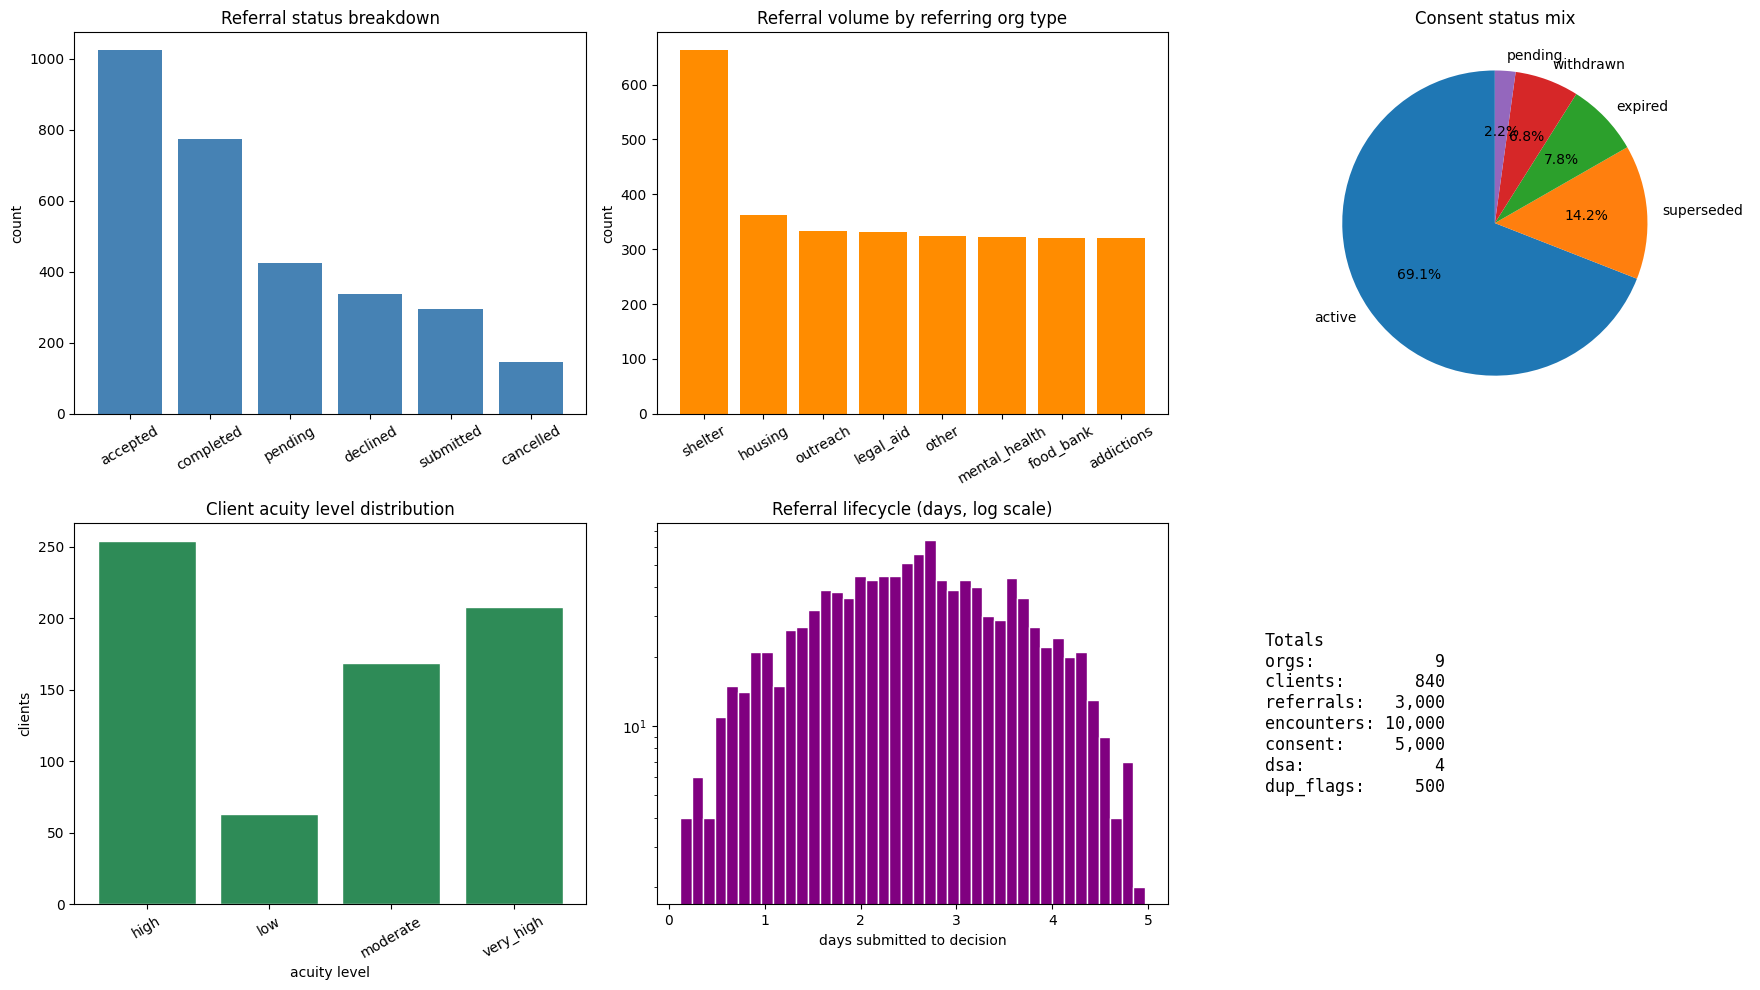

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Referral status breakdown
status_counts = referrals['status'].value_counts()
axes[0, 0].bar(status_counts.index, status_counts.values, color='steelblue')
axes[0, 0].set_title('Referral status breakdown')
axes[0, 0].set_ylabel('count')
axes[0, 0].tick_params(axis='x', rotation=30)

# 2. Referral volume by referring org type
by_ref_type = referrals_enriched['referring_org_type'].value_counts()
axes[0, 1].bar(by_ref_type.index, by_ref_type.values, color='darkorange')
axes[0, 1].set_title('Referral volume by referring org type')
axes[0, 1].set_ylabel('count')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. Consent status mix
consent_mix = consent['status'].value_counts()
axes[0, 2].pie(consent_mix.values, labels=consent_mix.index, autopct='%1.1f%%',
               startangle=90)
axes[0, 2].set_title('Consent status mix')

# 4. Client acuity level distribution
acuity_counts = clients['assessment_acuity_level'].dropna().value_counts().sort_index()
axes[1, 0].bar(acuity_counts.index, acuity_counts.values,
               color='seagreen', edgecolor='white')
axes[1, 0].set_title('Client acuity level distribution')
axes[1, 0].set_xlabel('acuity level')
axes[1, 0].set_ylabel('clients')
axes[1, 0].tick_params(axis='x', rotation=30)

# 5. Referral lifecycle time (submitted to completed or declined)
closed = referrals_enriched[referrals_enriched['status'].isin(
    ['completed', 'declined'])].copy()
closed['submitted_at'] = pd.to_datetime(closed['submitted_at'], errors='coerce')
closed['decision_at'] = pd.to_datetime(closed['decision_at'], errors='coerce')
closed['lifecycle_days'] = (closed['decision_at'] - closed['submitted_at']
                             ).dt.total_seconds() / 86400.0
lifecycle = closed['lifecycle_days'].dropna()
lifecycle = lifecycle[lifecycle > 0]
axes[1, 1].hist(lifecycle, bins=40, color='purple', edgecolor='white')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Referral lifecycle (days, log scale)')
axes[1, 1].set_xlabel('days submitted to decision')

# 6. Summary card
axes[1, 2].axis('off')
summary_text = (
    f"Totals\n"
    f"orgs:       {len(orgs):>6,}\n"
    f"clients:    {len(clients):>6,}\n"
    f"referrals:  {len(referrals):>6,}\n"
    f"encounters: {len(encounters):>6,}\n"
    f"consent:    {len(consent):>6,}\n"
    f"dsa:        {len(dsa):>6,}\n"
    f"dup_flags:  {len(dup_flags):>6,}"
)
axes[1, 2].text(0.05, 0.5, summary_text, fontfamily='monospace', fontsize=12,
                verticalalignment='center')

plt.tight_layout()
plt.show()

In [9]:
# Baseline: rule-based duplicate detector using Soundex-style bucketing + string similarity

# Converts a last name toa  4-character phonetic code
def soundex(name):
    if not isinstance(name, str) or not name:
        return '0000'
    name = name.upper()
    first = name[0]
    mapping = {'B': '1', 'F': '1', 'P': '1', 'V': '1',
               'C': '2', 'G': '2', 'J': '2', 'K': '2', 'Q': '2', 'S': '2', 'X': '2', 'Z': '2',
               'D': '3', 'T': '3',
               'L': '4',
               'M': '5', 'N': '5',
               'R': '6'}
    tail = ''.join(mapping.get(c, '') for c in name[1:])
    collapsed = ''
    prev = ''
    for c in tail:
        if c != prev:
            collapsed += c
        prev = c
    return (first + collapsed + '000')[:4]

# Takes two strings and returns a number from 0.0 to 1.0, representing similarity.
def sim(a, b):
    if not isinstance(a, str) or not isinstance(b, str):
        return 0.0
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

# Applies soundex to every last name
work = clients[['client_id', 'first_name', 'last_name', 'dob']].copy()
work['last_soundex'] = work['last_name'].apply(soundex)

pairs = []
# Groups clients by similar last name
for _, bucket in work.groupby('last_soundex'):
    # Skips too short or too long buckets
    if len(bucket) < 2 or len(bucket) > 80:
        continue
        # Converts bucket to dictionary
    recs = bucket.to_dict('records')
    for i in range(len(recs)):
        for j in range(i + 1, len(recs)):
            a, b = recs[i], recs[j]
            # Change this from before to after
            first_sim = sim(a['first_name'], b['first_name'])
            # TODO: change for a better format
            dob_match = 1.0 if pd.notna(a['dob']) and pd.notna(b['dob']) and a['dob'] == b['dob'] else 0.0
            score = 0.7 * first_sim + 0.3 * dob_match
            if score >= 0.75:
                pairs.append({
                    'client_id_a': a['client_id'],
                    'client_id_b': b['client_id'],
                    'score': round(score, 3),
                })

baseline = pd.DataFrame(pairs)
print(f'Baseline predicted {len(baseline)} duplicate pairs')


# Normalize pair direction so (a,b) == (b,a) for join
def keyify(row, a_col, b_col):
    a, b = row[a_col], row[b_col]
    return tuple(sorted([a, b]))


gt = dup_flags.copy()
gt['pair_key'] = gt.apply(lambda r: keyify(r, 'client_id_primary', 'client_id_secondary'), axis=1)
baseline['pair_key'] = baseline.apply(lambda r: keyify(r, 'client_id_a', 'client_id_b'), axis=1)

gt_true_keys = set(gt[gt['review_status'] == 'confirmed_duplicate']['pair_key'])
gt_all_keys = set(gt['pair_key'])
pred_keys = set(baseline['pair_key'])

tp = len(pred_keys & gt_true_keys)
fp = len(pred_keys - gt_true_keys)
fn = len(gt_true_keys - pred_keys)
precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-9)

print(f'\nBaseline vs ground truth:')
print(f'  true positives:  {tp}')
print(f'  false positives: {fp}')
print(f'  false negatives: {fn}')
print(f'  precision: {precision:.3f}')
print(f'  recall:    {recall:.3f}')
print(f'  f1:        {f1:.3f}')
print('\nBeat this.')

Baseline predicted 20 duplicate pairs

Baseline vs ground truth:
  true positives:  19
  false positives: 1
  false negatives: 34
  precision: 0.950
  recall:    0.358
  f1:        0.521

Beat this.


In [10]:
######### CUSTOM ENGINE 1 (no brute force)

# Baseline: rule-based duplicate detector using Soundex-style bucketing + string similarity
from dateutil import parser as dateparser
import jellyfish
# Documentation: https://github.com/life4/textdistance
import textdistance
# Converts a last name toa  4-character phonetic code

def soundex(name):
    if not isinstance(name, str) or not name:
        return '0000'
    name = name.upper()
    first = name[0]
    mapping = {'B': '1', 'F': '1', 'P': '1', 'V': '1',
               'C': '2', 'G': '2', 'J': '2', 'K': '2', 'Q': '2', 'S': '2', 'X': '2', 'Z': '2',
               'D': '3', 'T': '3',
               'L': '4',
               'M': '5', 'N': '5',
               'R': '6'
               # ,'A': '7', 'E': '7', 'H':'7','I': '7', 'O': '7', 'U': '7', 'W': '7', 'Y': '7'
              } # originally missing A, E, H, I, O, U, W, Y, 
    tail = ''.join(mapping.get(c, '') for c in name[1:])
    collapsed = ''
    prev = ''
    for c in tail:
        if c != prev:
            collapsed += c
        prev = c
    return (first + collapsed + '000')[:4]

# Takes two strings and returns a number from 0.0 to 1.0, representing similarity.
def sim(a, b):
    if not isinstance(a, str) or not isinstance(b, str):
        return 0.0
    return textdistance.editex.normalized_similarity(a.lower(), b.lower())

# Applies soundex to every last name
def soundex_sorted(name):
    code = soundex(name)
    return code[0] + ''.join(sorted(code[1:])) #keeps first character, sorts remaining digits in ascending order.

work = clients[['client_id', 'first_name', 'last_name', 'aliases','dob']].copy()
work['last_soundex'] = work['last_name'].apply(soundex_sorted)
pairs = []
# Groups clients by similar last name
for _, bucket in work.groupby('last_soundex'):

    if len(bucket) < 2 or len(bucket) > 80:
        continue
        # Converts bucket to dictionary
    recs = bucket.to_dict('records')
    for i in range(len(recs)):
        for j in range(i + 1, len(recs)):
            a, b = recs[i], recs[j]

            first_sim = sim(a['first_name'], b['first_name']) 
            last_sim = sim(a['last_name'], b['last_name'])
            if first_sim < 0.6:
                p1 = 0
                p2 = 0
                if pd.notna(b['aliases']):
                    p1 = (sim(a['first_name'], b['aliases']))
                    
                if pd.notna(a['aliases']):
                    p2 = (sim(a['aliases'], b['first_name']))
                
                first_sim = max(p1, p2)
            
            try:
                if pd.notna(a['dob']) and pd.notna(b['dob']):
                    a_date = dateparser.parse(a['dob'], dayfirst=True).date()
                    b_date = dateparser.parse(b['dob'], dayfirst=True).date()
                    if a_date == b_date:
                        dob_match = 1.0
                    else: dob_match = 0.0
                else:
                    dob_match = 0.0
            except Exception:
                dob_match = 0.0
                
            score = 0.35 * first_sim + 0.35*last_sim + 0.3 * dob_match
            try:
                if pd.notna(a['dob']) and pd.notna(b['dob']) and dob_match == 0.0: score *= 0.7
            except Exception:
                dob_match = 0.0
            
            if score >= 0.56 and first_sim >= 0.5:
                pairs.append({
                    'client_id_a': a['client_id'],
                    'client_id_b': b['client_id'],
                    'score': round(score, 3),
                })

baseline = pd.DataFrame(pairs)
print(f'Baseline predicted {len(baseline)} duplicate pairs')


# Normalize pair direction so (a,b) == (b,a) for join
def keyify(row, a_col, b_col):
    a, b = row[a_col], row[b_col]
    return tuple(sorted([a, b]))


gt = dup_flags.copy()
gt['pair_key'] = gt.apply(lambda r: keyify(r, 'client_id_primary', 'client_id_secondary'), axis=1)
baseline['pair_key'] = baseline.apply(lambda r: keyify(r, 'client_id_a', 'client_id_b'), axis=1) # PROBLEM HERE

gt_true_keys = set(gt[gt['review_status'] == 'confirmed_duplicate']['pair_key'])
gt_all_keys = set(gt['pair_key'])
pred_keys = set(baseline['pair_key'])

tp = len(pred_keys & gt_true_keys)
fp = len(pred_keys - gt_true_keys)
fn = len(gt_true_keys - pred_keys)
precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-9)

print(f'\nNew duplicate detector:')
print(f'  true positives:  {tp}')
print(f'  false positives: {fp}')
print(f'  false negatives: {fn}')
print(f'  precision: {precision:.3f}')
print(f'  recall:    {recall:.3f}')
print(f'  f1:        {f1:.3f}')


#########

Baseline predicted 36 duplicate pairs

New duplicate detector:
  true positives:  34
  false positives: 2
  false negatives: 19
  precision: 0.944
  recall:    0.642
  f1:        0.764


In [13]:
# See what the algorithm missed
confirmed = dup_flags[dup_flags['review_status'].isin(['confirmed_duplicate'])]
cols = ['client_id', 'primary_org_id', 'first_name', 'last_name', 'middle_name', 'aliases', 'dob', 'phone', 'email']
fp_keys = pred_keys - gt_true_keys
fn_keys = gt_true_keys - pred_keys
# Load your files
clients_subset = clients[cols]
for x in fn_keys:
    id_a, id_b = x
    pair = clients_subset[clients_subset['client_id'].isin([id_a, id_b])]
    print(pair.to_string(index=False))
    
    print('-' * 60)

client_id primary_org_id first_name last_name middle_name aliases        dob          phone                 email
 CLI-0007       ORG-0004       Adam        le        None    None 1994-11-10 (250) 592-6761                  None
 CLI-0581       ORG-0001     Sherry    Deleon    Danielle    None 04/05/1981        Unknown melissa78@example.com
------------------------------------------------------------
client_id primary_org_id first_name last_name middle_name aliases        dob          phone                 email
 CLI-0138       ORG-0004    ANTHONY    WRIGHT        None    None 2006-03-16 (250) 726-8641               Unknown
 CLI-0774       ORG-0001      TONYA    Wilson        None  Yvonne 1983-05-26   250-387-9767 anthony66@example.org
------------------------------------------------------------
client_id primary_org_id  first_name  last_name middle_name aliases        dob        phone                   email
 CLI-0262       ORG-0004     matthew    Daniels      Robert    None 05/04/2000

In [12]:
# This code allows you to see all possible duplicates
"""
confirmed = dup_flags[dup_flags['review_status'].isin(['confirmed_duplicate'])]
cols = ['client_id', 'primary_org_id', 'first_name', 'last_name', 'middle_name', 'aliases', 'dob', 'phone', 'email']
fp_keys = pred_keys - gt_true_keys
fn_keys = gt_true_keys - pred_keys
# Load your files
clients_subset = clients[cols]
for x in fn_keys:
    id_a, id_b = x
    pair = clients_subset[clients_subset['client_id'].isin([id_a, id_b])]
    print(pair.to_string(index=False))
    
    print('-' * 60)
"""

"\nconfirmed = dup_flags[dup_flags['review_status'].isin(['confirmed_duplicate'])]\ncols = ['client_id', 'primary_org_id', 'first_name', 'last_name', 'middle_name', 'aliases', 'dob', 'phone', 'email']\nfp_keys = pred_keys - gt_true_keys\nfn_keys = gt_true_keys - pred_keys\n# Load your files\nclients_subset = clients[cols]\nfor x in fn_keys:\n    id_a, id_b = x\n    pair = clients_subset[clients_subset['client_id'].isin([id_a, id_b])]\n    print(pair.to_string(index=False))\n\n    print('-' * 60)\n"

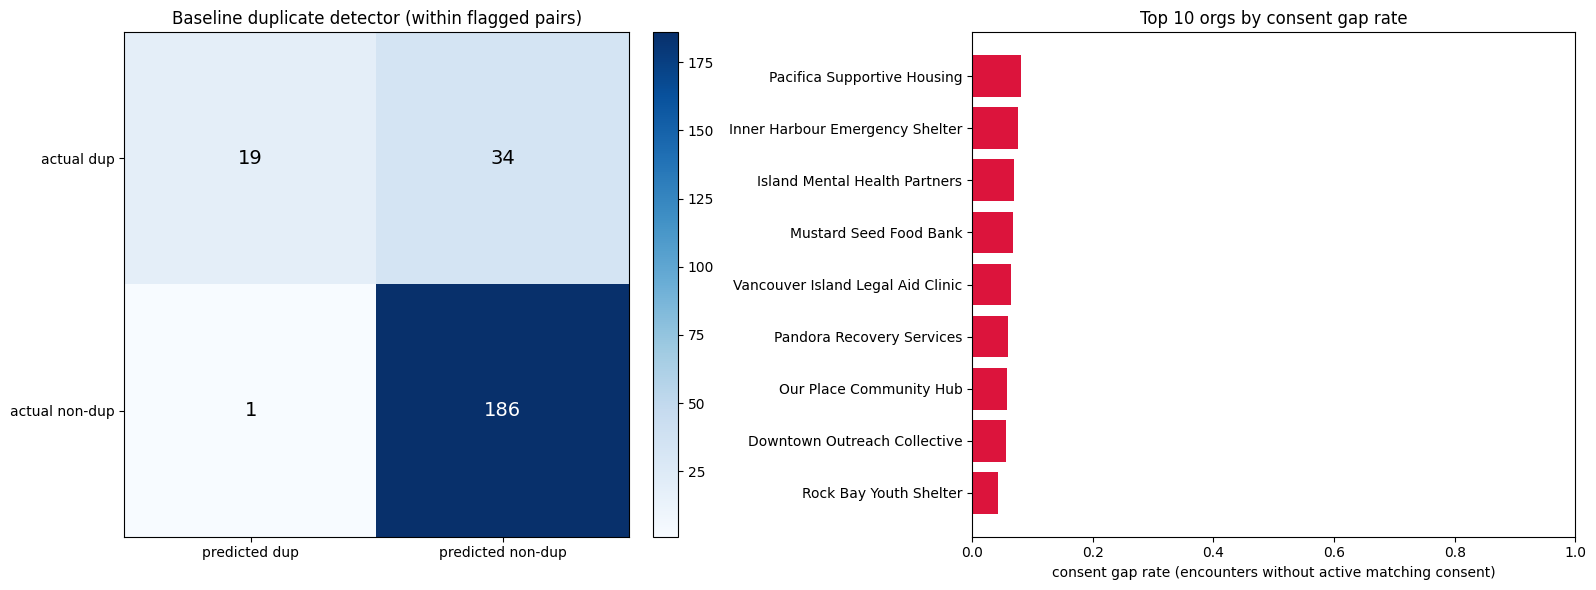

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Confusion matrix heatmap for baseline vs ground truth
tn_approx = len(gt_all_keys) - tp - fp - fn
cm = np.array([[tp, fn],
               [fp, max(tn_approx, 0)]])
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['predicted dup', 'predicted non-dup'])
axes[0].set_yticklabels(['actual dup', 'actual non-dup'])
axes[0].set_title('Baseline duplicate detector (within flagged pairs)')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black',
                     fontsize=14)
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# (b) Top 10 orgs by consent gap rate
enc = encounters.merge(
    clients[['client_id', 'current_consent_id']], on='client_id', how='left'
).merge(
    consent[['consent_id', 'status', 'expiry_date']].rename(
        columns={'consent_id': 'current_consent_id'}),
    on='current_consent_id', how='left'
)
enc['encounter_start'] = pd.to_datetime(enc['encounter_start'], errors='coerce')
enc['expiry_date'] = pd.to_datetime(enc['expiry_date'], errors='coerce')
enc['has_gap'] = (
    enc['status'].isna()
    | (enc['status'].isin(['expired', 'withdrawn']))
    | ((enc['expiry_date'].notna()) & (enc['encounter_start'] > enc['expiry_date']))
)

gap_by_org = enc.merge(orgs[['org_id', 'org_name']], on='org_id', how='left')
gap_stats = gap_by_org.groupby('org_name').agg(
    encounters=('encounter_id', 'count'),
    gaps=('has_gap', 'sum'),
)
gap_stats['gap_rate'] = gap_stats['gaps'] / gap_stats['encounters']
gap_stats = gap_stats.sort_values('gap_rate', ascending=False).head(10)

axes[1].barh(gap_stats.index[::-1], gap_stats['gap_rate'].values[::-1], color='crimson')
axes[1].set_xlabel('consent gap rate (encounters without active matching consent)')
axes[1].set_title('Top 10 orgs by consent gap rate')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## Extension ideas and rubric alignment

The baseline above is deliberately simple. Here is where to go next, mapped to the 4 judging themes.

### Build ideas

- **ML-based entity resolution** with Splink or recordlinkage. Learn agreement weights from the seeded duplicate pairs. Handle Indigenous name variants and nicknames without leaking OCAP-protected attributes into public features.
- **Embedding-based name matching** using sentence-transformers on `first_name + last_name + dob + address`. Catches phonetic and transliteration variants that Soundex misses.
- **Live consent-gap dashboard** (Streamlit or Next.js) that shows caseworkers a red banner the moment they pull a record whose consent is expired, withdrawn, or scope-mismatched.
- **Referral decline predictor** that estimates probability of `status = declined` at submission time from client acuity, referring/receiving org pair, and encounter history.
- **Care-coordination API** that exposes a single endpoint `/clients/{id}/safe-view` which automatically redacts fields based on OCAP and `sharing_scope_type`.
- **Falling-through-the-gaps risk score** combining VI-SPDAT, days since last encounter, consent expiry, and referral decline history.

### Rubric alignment

| Judging theme | What moves the needle |
| --- | --- |
| **Problem Fit** | You can name the operational pain (duplicate-client triage, unlawful data sharing, silent referral death) and show your solution removes it. Include a before/after caseworker workflow. |
| **Technical Merit** | Beat the baseline F1 on duplicates. Show ROC curves, ablations, or calibration plots. No magic numbers, no hand-tuned thresholds that happen to fit the seeded pairs. |
| **Social Services Domain Grounding** | References to HIFIS 4 field names, AIRS taxonomy codes, VI-SPDAT bands, and correct handling of OCAP and PIPA/FOIPPA. Judges include people who have operated these systems. |
| **Production Readiness** | Tests, schema validation, a runnable demo, and a clear story on privacy, observability, and failure modes. A notebook alone does not qualify. |

### Before you submit

- Re-read `../docs/problem-framing.md` once more. Make sure your solution honors every privacy constraint listed there.
- Record a 3 minute walkthrough. Judges watch everything at 1.5x. Be clear and specific.
- Put your repo URL, demo URL, and a 150-word abstract in your submission form.

In [11]:
print(dup_flags['possible_duplicate_reason'].value_counts())

possible_duplicate_reason
alias_cross_ref                        65
exact_name_dob_match                   63
phonetic_name_match                    62
phone_only_match                       59
family_member_overlap                  56
shared_address_but_different_person    53
same_first_name_only                   52
address_drift_match                    51
loose_phonetic                         39
Name: count, dtype: int64


In [12]:
print(dup_flags['review_status'].value_counts())

review_status
unreviewed             241
not_duplicate          129
confirmed_duplicate    106
merged                  24
Name: count, dtype: int64
